<a href="https://colab.research.google.com/github/Anubhavkumar076/ai_data_analysis/blob/main/Personal_Loan_Campaign.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement

### Context

AllLife Bank is a mid-sized, fast-growing US-based financial institution that offers a range of retail banking services, including savings and checking accounts, fixed deposits, and personal loans. The bank’s business model is centered on building long-term customer relationships, expanding its retail footprint, and growing its loan portfolio to drive sustainable profitability through interest income.

 It currently relies on a large base of liability customers (depositors) but faces a significant under-representation of asset customers (borrowers). To drive profitability through interest income, the bank must aggressively expand its loan portfolio by converting existing depositors into personal loan customers.

 Last year’s pilot campaign achieved a 9% conversion rate, validating the potential of this strategy. However, to optimize marketing spend and improve efficiency, the retail marketing department requires a more data-driven approach. Enhancing the success ratio of these campaigns is critical for sustainable growth and maximizing customer lifetime value.


 ### Objective

The objective is to develop a predictive classification model that identifies patterns and key factors driving personal loan adoption among existing liability customers. By uncovering the demographic and behavioral drivers of loan conversion, the goal is to enable targeted segmentation and more precise marketing interventions that improve campaign conversion rates, optimize marketing spend, and enhance overall profitability through higher-quality loan portfolio growth.

## Data Dictionary
**ID:** Customer ID

**Age:** Customer’s age in completed years

**Experience:** # years of professional experience

**Income:** Annual income of the customer (in thousand dollars)

**ZIP Code:** Home Address ZIP code.

**Family:** The family size of the customer

**CCAvg:** Average spending on credit cards per month (in thousand dollars)

**Education:** Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional

**Mortgage:** Value of house mortgage if any. (in thousand dollars)

**Personal_Loan:** Did this customer accept the personal loan offered in the last campaign?

**Securities_Account:** Does the customer have a securities account with the bank?

**CD_Account:** Does the customer have a certificate of deposit (CD) account with the bank?

**Online:** Do customers use Internet banking facilities?

**CreditCard:** Does the customer use a credit card issued by any other Bank (excluding All Life Bank)?

In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

# Libraries to build decision tree classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To tune different models
from sklearn.model_selection import GridSearchCV

# To perform statistical analysis
import scipy.stats as stats

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix
)

# Library to suppress warnings or deprecation notes
import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [ ]:
data = pd.read_csv("Loan_Modelling.csv")

In [ ]:
# copying data to another varaible to avoid any changes to original data
df = data.copy()

## Data Overview

In [ ]:
# View the first 5 rows of the dataset.
df.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [ ]:
# View the first 5 rows of the dataset.
df.tail()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


### Understand the shape of the dataset.

In [ ]:
df.shape

(5000, 14)



*   The dataset has 5000 rows and 14 columns of data



### Check the data types of the columns for the dataset.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB




*   All columns are of integer data type, except for 'CCAvg' which is a float.
*   As per the above head and tail sample, We can see Personal_Loan, Securities_Account, CD_Account, Online and CreditCard contains binary value (0/1), these are categorical variable with int data type.



### Checking the existence of null value

In [ ]:
df.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0




*   There is no null value in the dataset.



### Checking the existence of duplicate value

In [ ]:
# checking for duplicate values
df.duplicated().sum()

np.int64(0)

*   There is no duplicate value in the dataset.

### Checking unique value

In [ ]:
# checking for unique values in ID column
df['ID'].nunique()

5000

*   Since all the values in ID column are unique we can drop it

In [ ]:
df.drop('ID', axis = 1, inplace = True)

### Statistical summary of the dataset

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,45.338400,11.463166,23.0,35.0,45.0,55.0,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.0,20.0,30.0,43.0
Income,5000.0,73.774200,46.033729,8.0,39.0,64.0,98.0,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.0,93437.0,94608.0,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.0,2.0,3.0,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.7,1.5,2.5,10.0
Education,5000.0,1.881000,0.839869,1.0,1.0,2.0,3.0,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.0,0.0,101.0,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.0,0.0,0.0,1.0
Securities_Account,5000.0,0.104400,0.305809,0.0,0.0,0.0,0.0,1.0


#### Observation from statistical summary


*   **Age and Experience:** The minimum experience is -3 years, which is an anomaly as experience cannot be negative. This will need to be addressed.
*   **Income:** Income ranges from 8 to 224 (in thousand dollars), with a mean of approximately 73.77 thousand dollars.
*   **ZIPCode:** These are geographic identifiers and not numerical values to be analyzed statistically.
*   **Family:** There is maximum 4 member in the family, and the mean value is around 2.
*   **CCAvg:** Credit card spending averages around 1.94 thousand dollars per month, with a maximum of 10 thousand dollars.
*   **Education:** This is a categorical variable, represented numerically (1, 2, 3), and Advanced/Professional ranges between 25% to 50%.
*   **Mortgage:** A significant number of customers have a mortgage of 0, indicating many do not have a mortgage. The maximum mortgage value is 635 thousand dollars.
*   **Personal_Loan, Securities_Account, CD_Account, Online, CreditCard:** These are binary (0/1) variables. The mean represents the proportion of customers with these features. For instance, only about 9.6% of customers have accepted a personal loan, while nearly 60% use online banking.












In [ ]:
# Converting negative experience into absolute value
df['Experience'] = np.abs(df['Experience'])

In [ ]:
(df['Experience'] < 0).sum()

np.int64(0)



*   We've updated all the negative experience with its absolute value.



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   int64  
 2   Income              5000 non-null   int64  
 3   ZIPCode             5000 non-null   int64  
 4   Family              5000 non-null   int64  
 5   CCAvg               5000 non-null   float64
 6   Education           5000 non-null   int64  
 7   Mortgage            5000 non-null   int64  
 8   Personal_Loan       5000 non-null   int64  
 9   Securities_Account  5000 non-null   int64  
 10  CD_Account          5000 non-null   int64  
 11  Online              5000 non-null   int64  
 12  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 507.9 KB


## Exploratory Data Analysis (EDA) Summary

In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [ ]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [ ]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

### Univariate Analysis

#### Univariate Analysis on Numerical Columns

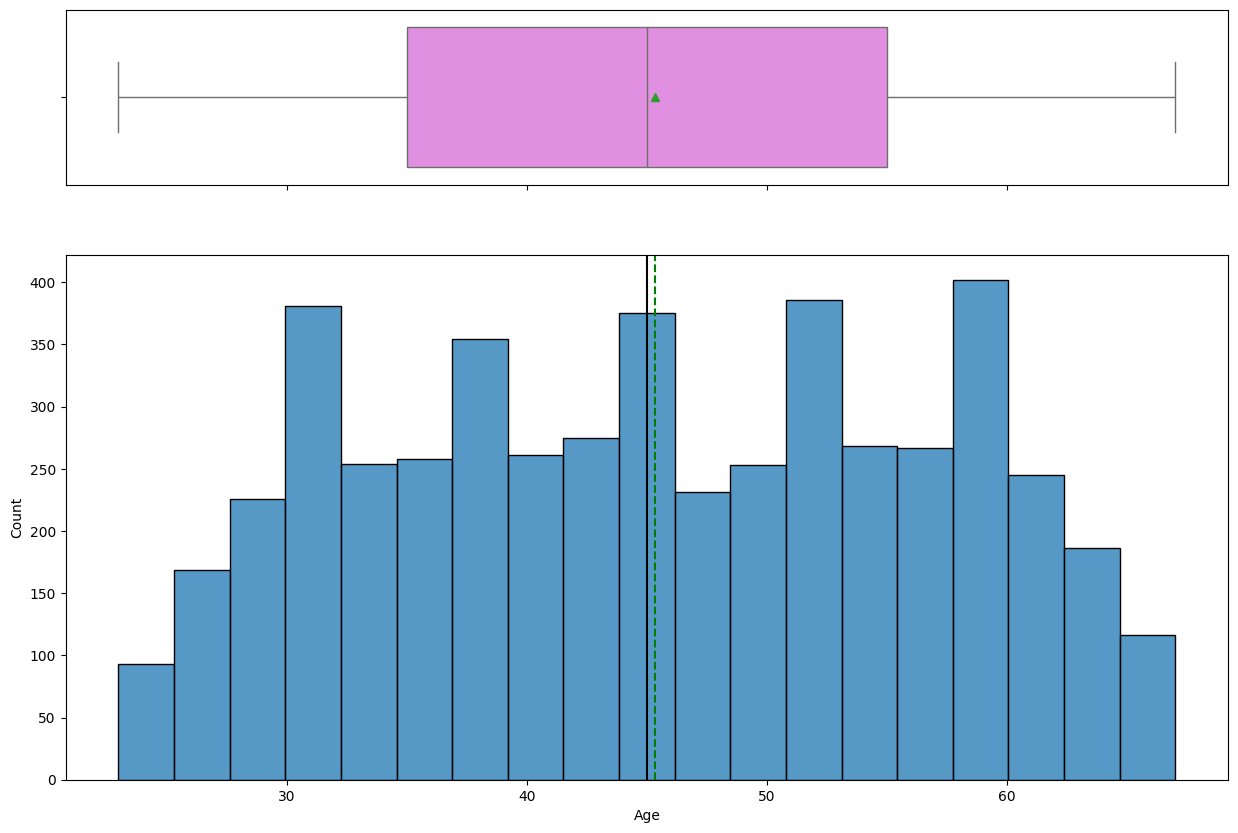

In [ ]:
# Analysis for Age
histogram_boxplot(df, 'Age')

##### Observations on Age:

*   Data looks fairly uniform with no skewness and there is no outliers.
*   Mean and Median both are almost aligned with each other i.e. 45 years.



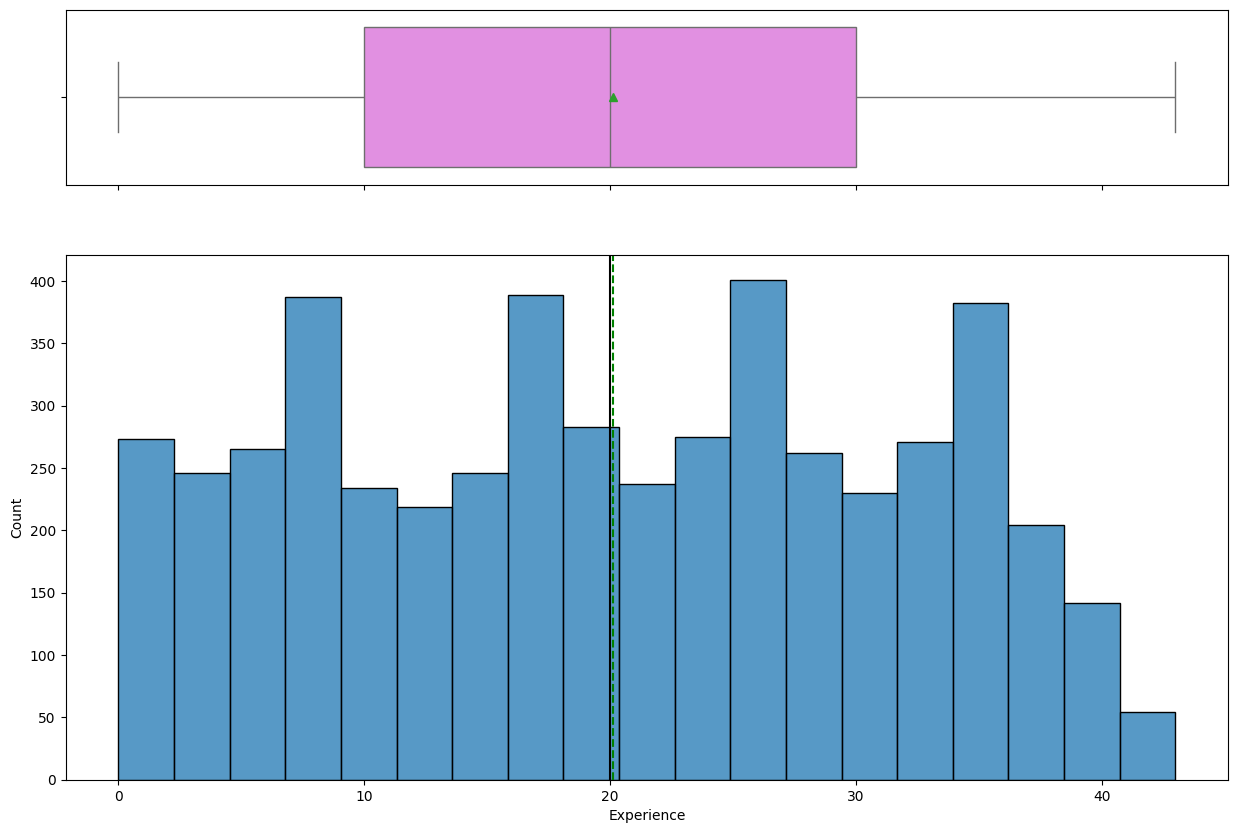

In [ ]:
# Analysis for Experience
histogram_boxplot(df, 'Experience')

##### Observations on Experience:

*   Data looks same as age with no skewness and there is no outliers.
*   Mean and Median both are almost aligned with each other i.e. 20 years.



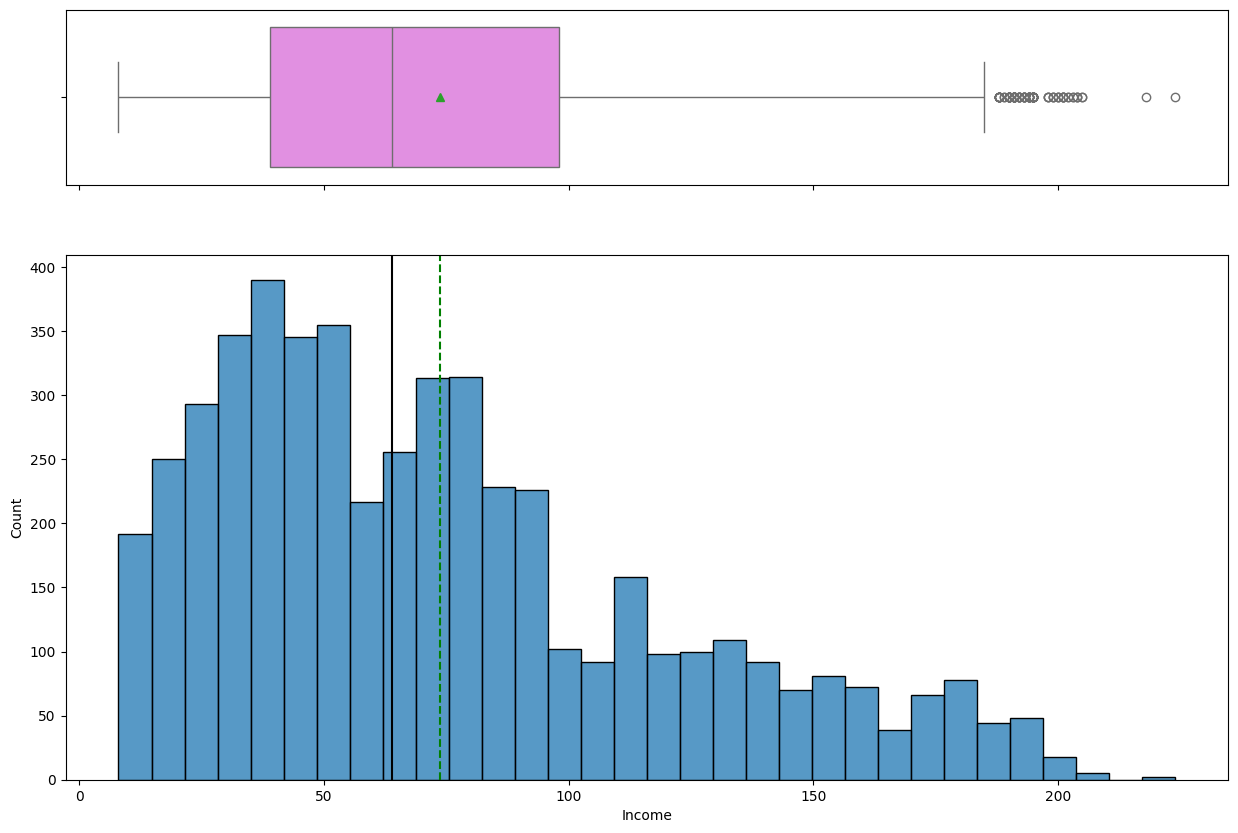

In [ ]:
# Analysis for Income
histogram_boxplot(df, 'Income')

##### Observations on Income:

*   Income has rightly skewed data, which is also visible in box plot via outliers.
*   Mean and median both are in between 50 to 100 thousand dollar, however mean is slightly greater than median which is confirming the right skewness.



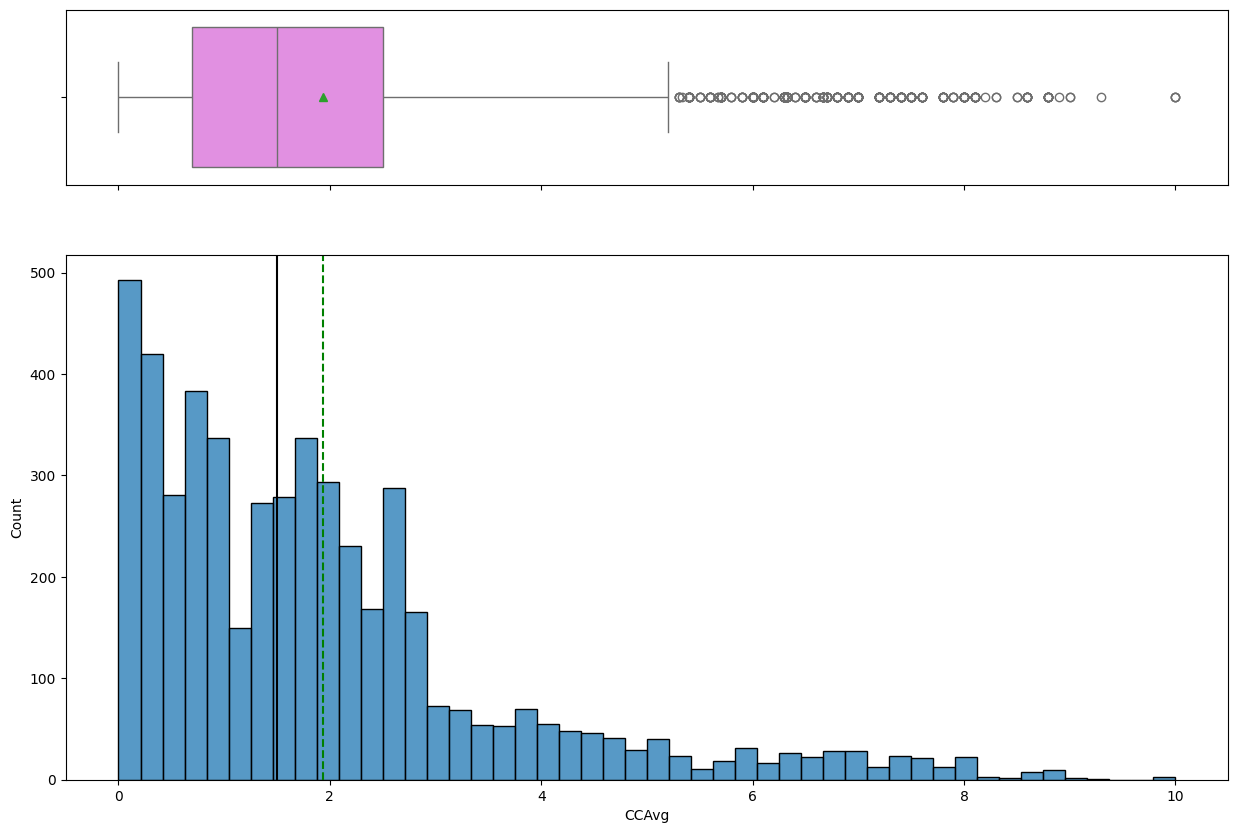

In [ ]:
# Analysis for CCAvg
histogram_boxplot(df, 'CCAvg')

##### Observations on CCAvg:

*   Average credit card spend is also rightly skewed, with few outliers which supports income data trend.
*   Mean and median data point is also similar to what we saw in income data trend, which is expected.



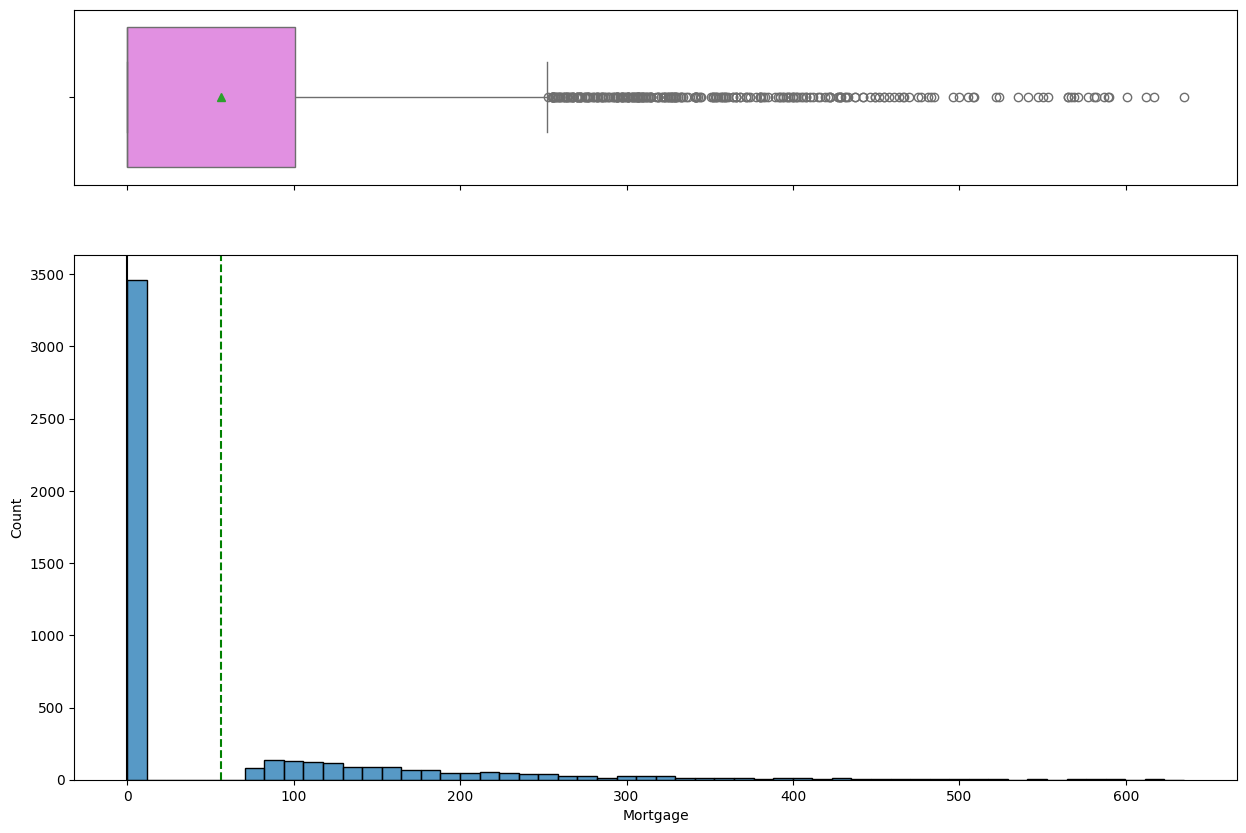

In [ ]:
# Analysis for Mortgage
histogram_boxplot(df, 'Mortgage')

##### Observations on Mortgage:

*   Mortage data trend is highly right skewed with a lot of outliers.
*   We have observed in statistical data point as well, that a lot of customer is standing on 0 for this.



#### Univariate Analysis on Categorical Columns

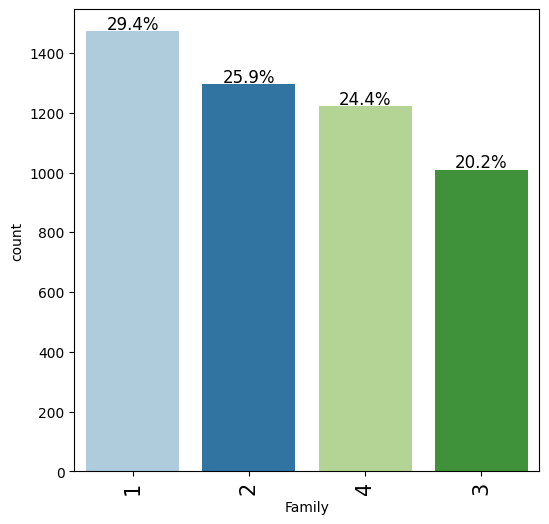

In [ ]:
# Analysis for Family
labeled_barplot(df, 'Family', True)

##### Observations on Family:

*   Family with 1 and 2 members are more than 25%.
*   Family with 3 and 4 members are also visible in significant number.



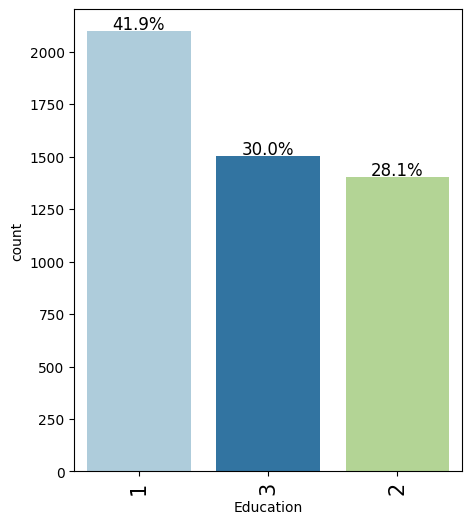

In [ ]:
# Analysis for Education
labeled_barplot(df, 'Education', True)

##### Observations on Education:

*   More than 41% customers are undergrad student.
*   Graduated and Professional customers are also has significant number with 28% and 30% respectively.



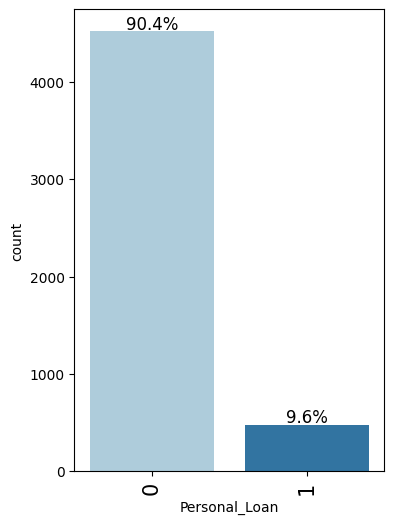

In [ ]:
# Analysis for Personal_Loan
labeled_barplot(df, 'Personal_Loan', True)

##### Observations on Personal Loan:

*   Only 9% of customers are having personal loan.
*   This is indicating a highly imbalanced dataset, which need to be considered during model training.



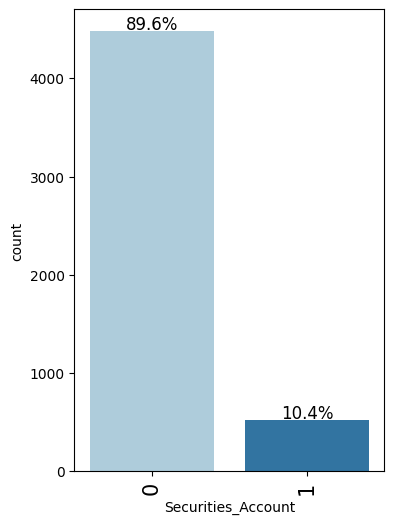

In [ ]:
# Analysis for Securities_Account
labeled_barplot(df, 'Securities_Account', True)

##### Observations on Personal Loan:

*   10% customers only have securities account with the bank.
*   This also has same kind of imbalanced dataset we have seen for personal loan.



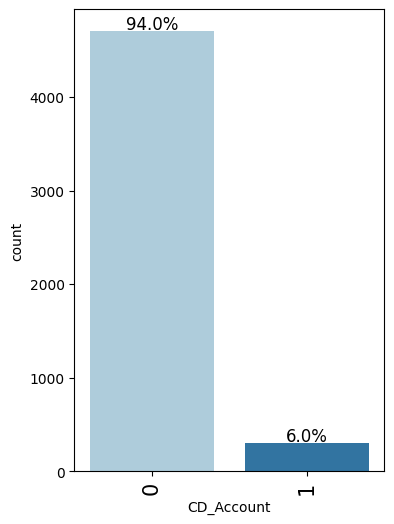

In [ ]:
# Analysis for CD_Account
labeled_barplot(df, 'CD_Account', True)

##### Observations on CD Account:
*   Larger majority (about 94%) of customers do not have a Certificate of Deposit (CD) account with the bank.

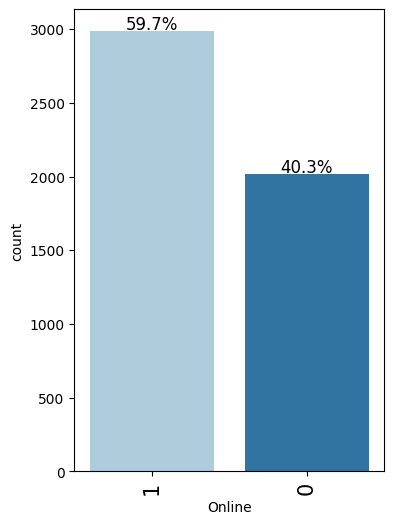

In [ ]:
# Analysis for Online
labeled_barplot(df, 'Online', True)

##### Observations on Online:
*   Almost 60% customers are using online banking facilities.
*  There are still significant number of users who are still not using this.

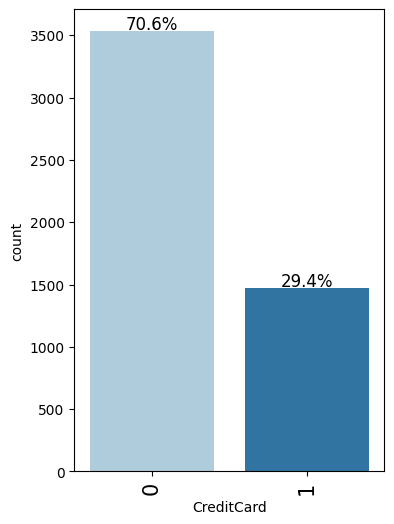

In [ ]:
# Analysis for CreditCard
labeled_barplot(df, 'CreditCard', True)

##### Observations on Online:
*   There are 29% credit card holders, who are using card from other bank. It shows there are notable segment of customers who are using competitor's credit card.

### Bivariate Analysis

#### Correlation Check

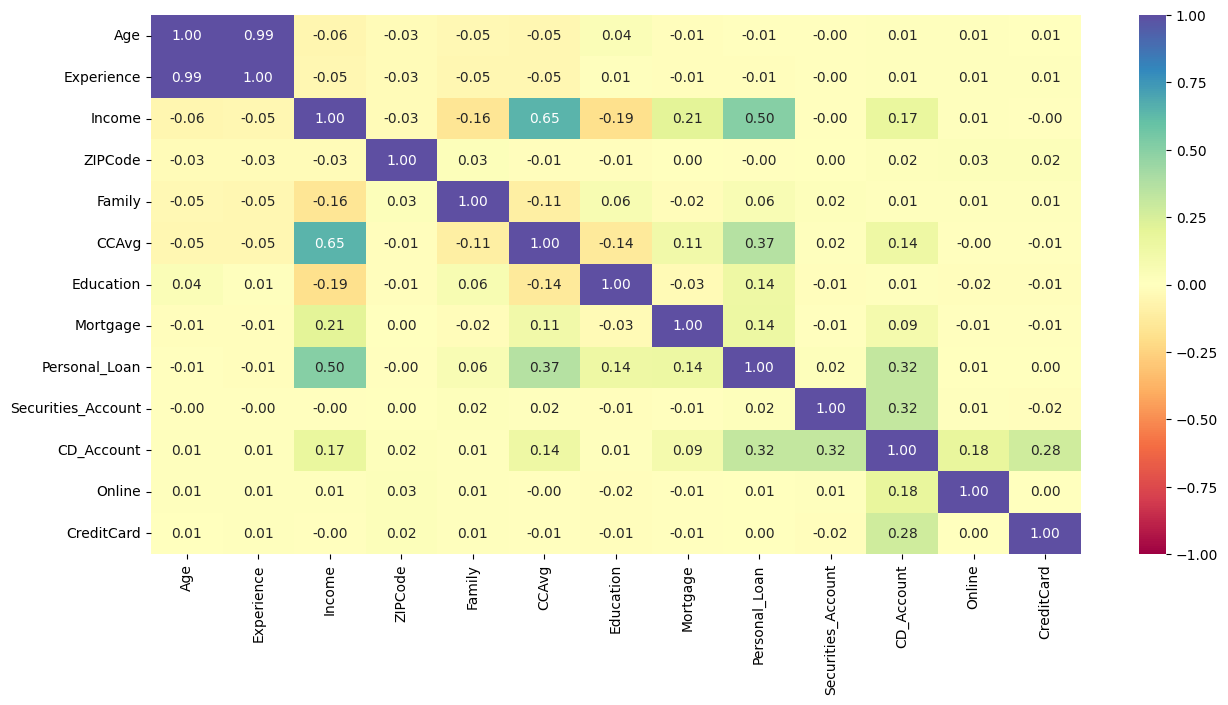

In [ ]:
plt.figure(figsize=(15, 7))
sns.heatmap(df.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

##### Observations on Coorelation:
*   As expected Age and Experience are highly correlated to each other.
*   Income, Perosnal loan, CCAvg are highly related to each other.
*   CD_Account, Securities_Account and Personal_Loan are also correlated with each other.
*   ZipCode is not adding any value as of now which is expected.
*   Education, Family, Age and Experience are also not adding much value as per heat map. However, these will be very useful for latter bivariate analysis.

#### Bivariate Analysis between Income and Personal Loan

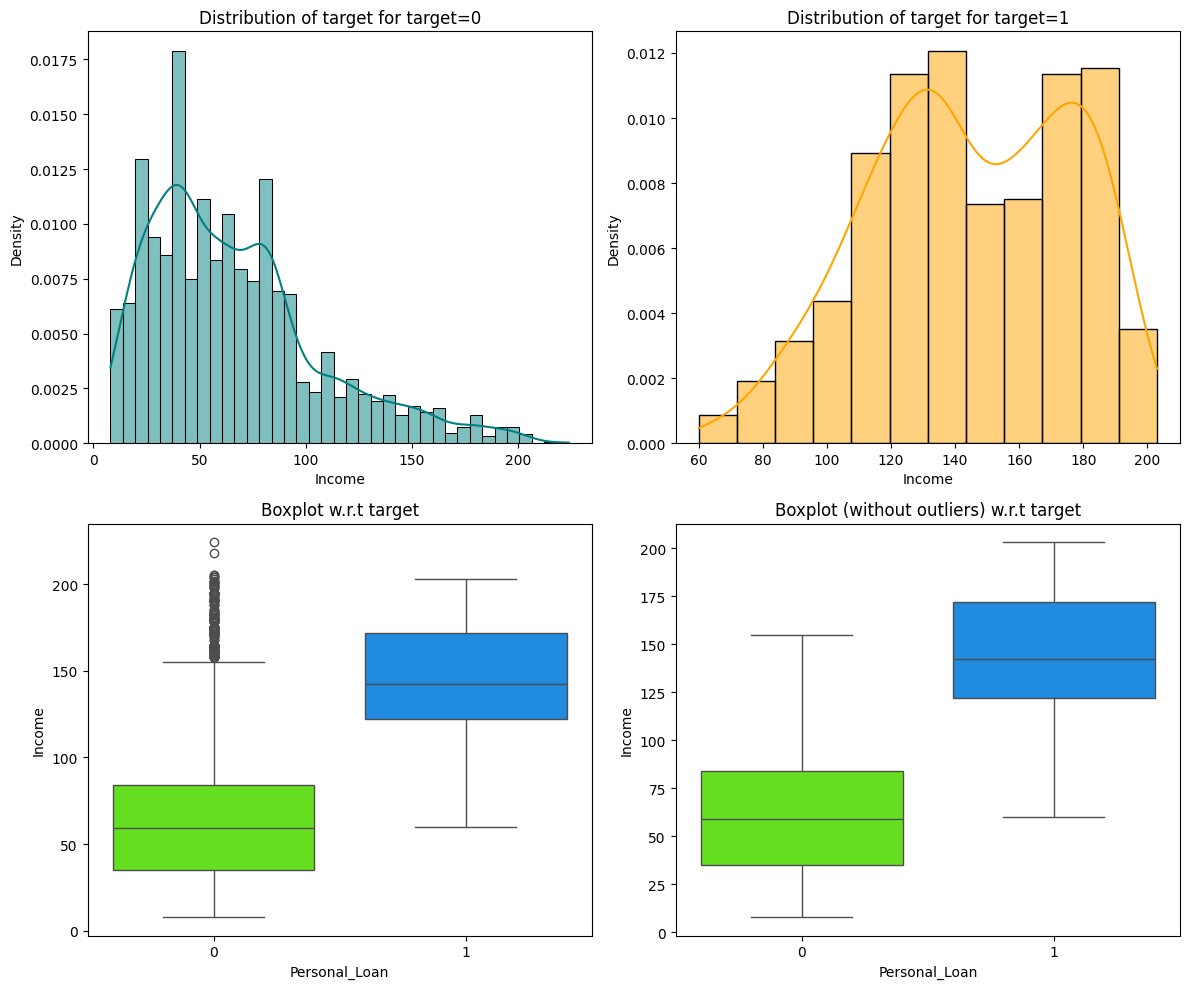

In [ ]:
# Analyze 'Income' vs 'Personal_Loan'
distribution_plot_wrt_target(df, 'Income', 'Personal_Loan')

##### Observations on Income vs. Personal Loan:
*   There is a significant difference in income distribution between customers who accepted a personal loan and those who did not.
*   Customers who accepted a personal loan tend to have considerably higher incomes, indicating income is a strong predictor of loan acceptance.
*   The box plots clearly show that the median and average income for loan acceptors are much higher.

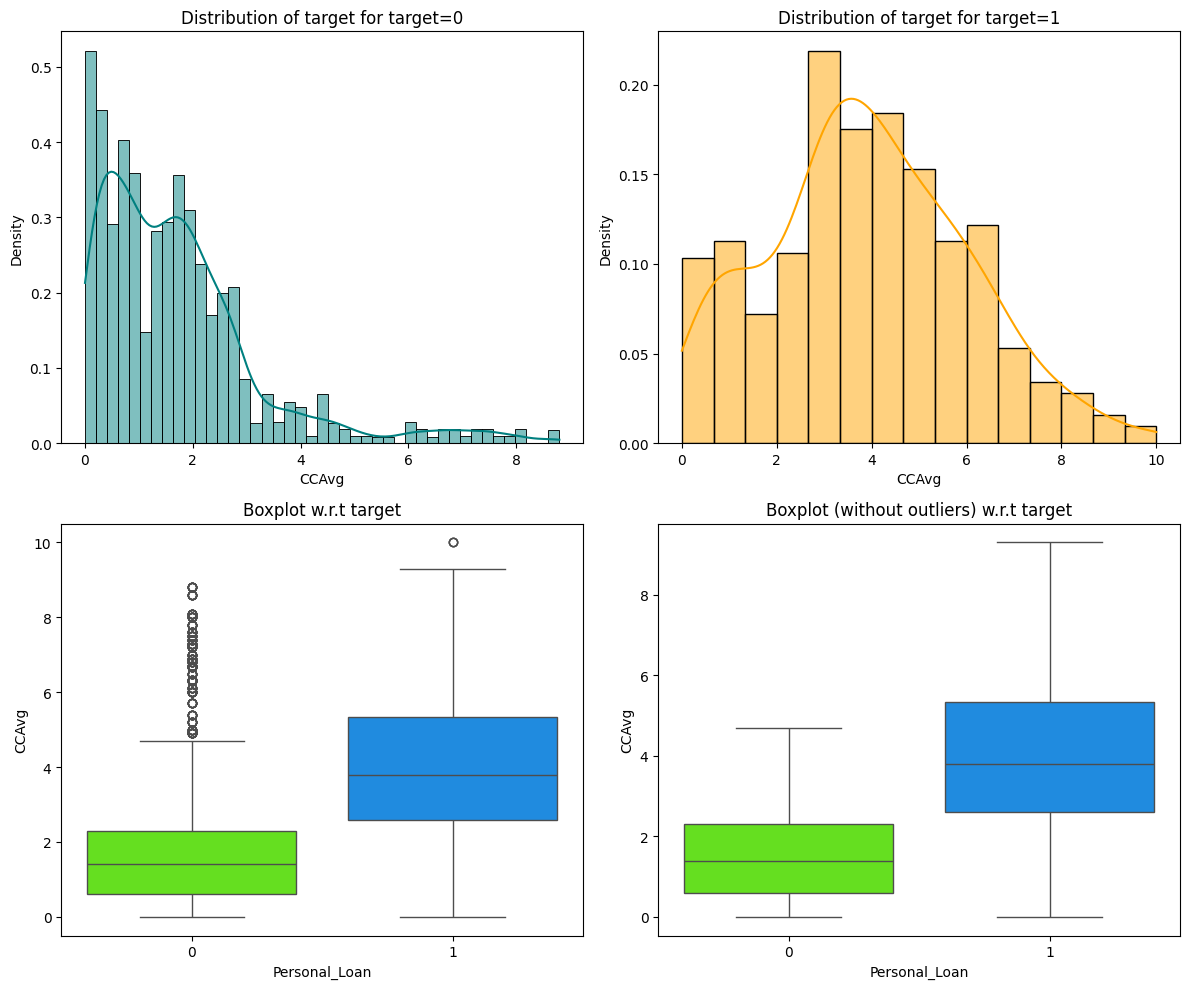

In [ ]:
# Analyze 'CCAvg' vs 'Personal_Loan'
distribution_plot_wrt_target(df, 'CCAvg', 'Personal_Loan')

##### Observations on CCAvg vs. Personal Loan:
*   Similar to income, there's a clear distinction in average credit card spending (`CCAvg`) between the two groups.
*   Customers who accepted personal loans tend to have higher average credit card spending, suggesting a correlation between higher spending habits and willingness to take a loan.

Personal_Loan     0    1   All
Education                     
All            4520  480  5000
3              1296  205  1501
2              1221  182  1403
1              2003   93  2096
------------------------------------------------------------------------------------------------------------------------


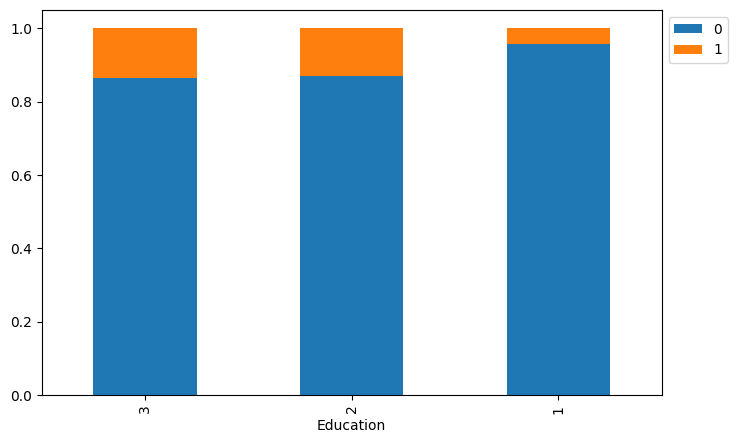

In [ ]:
# Analyze 'Education' vs 'Personal_Loan'
stacked_barplot(df, 'Education', 'Personal_Loan')

##### Observations on Education vs. Personal Loan:
*   Education level appears to be a strong indicator of personal loan acceptance.
*   Customers with 'Education' level 3 (Advanced/Professional) have a significantly higher rate of personal loan acceptance compared to those with levels 1 (Undergrad) and 2 (Graduate).
*   This suggests a positive correlation between higher education and loan acceptance.

Personal_Loan     0    1   All
CD_Account                    
All            4520  480  5000
0              4358  340  4698
1               162  140   302
------------------------------------------------------------------------------------------------------------------------


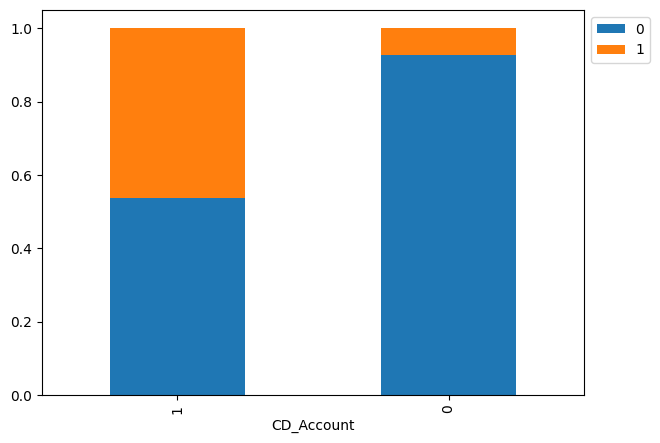

In [ ]:
# Analyze 'CD_Account' vs 'Personal_Loan'
stacked_barplot(df, 'CD_Account', 'Personal_Loan')

##### Observations on CD_Account vs. Personal Loan:
*   Customers with CD_Account tend to have higher rate of personal loan.
*   This suggests a positive correlation between CD_Account holder and loan acceptance. However, there are comparetively very small number of customers having CD_Account with respect to the customers who don't.

Personal_Loan          0    1   All
Securities_Account                 
All                 4520  480  5000
0                   4058  420  4478
1                    462   60   522
------------------------------------------------------------------------------------------------------------------------


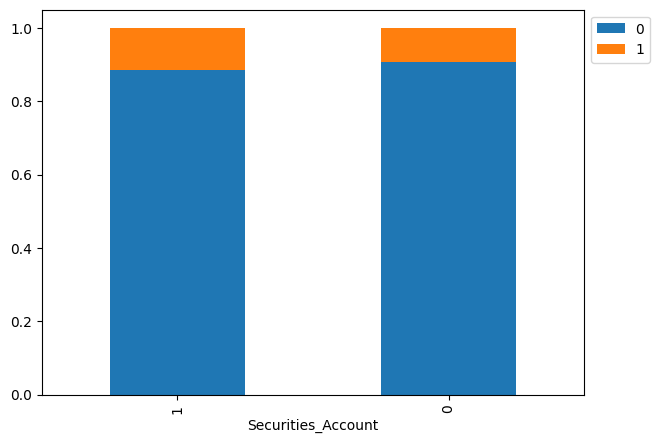

In [ ]:
# Analyze 'Securities_Account' vs 'Personal_Loan'
stacked_barplot(df, 'Securities_Account', 'Personal_Loan')

##### Observations on Securities_Account vs. Personal Loan:
*   Customers with Securities_Account have higher rate of loan acceptance but the gap is marginally small to conclude anything.


## Data Preprocessing

### Outlier Detection

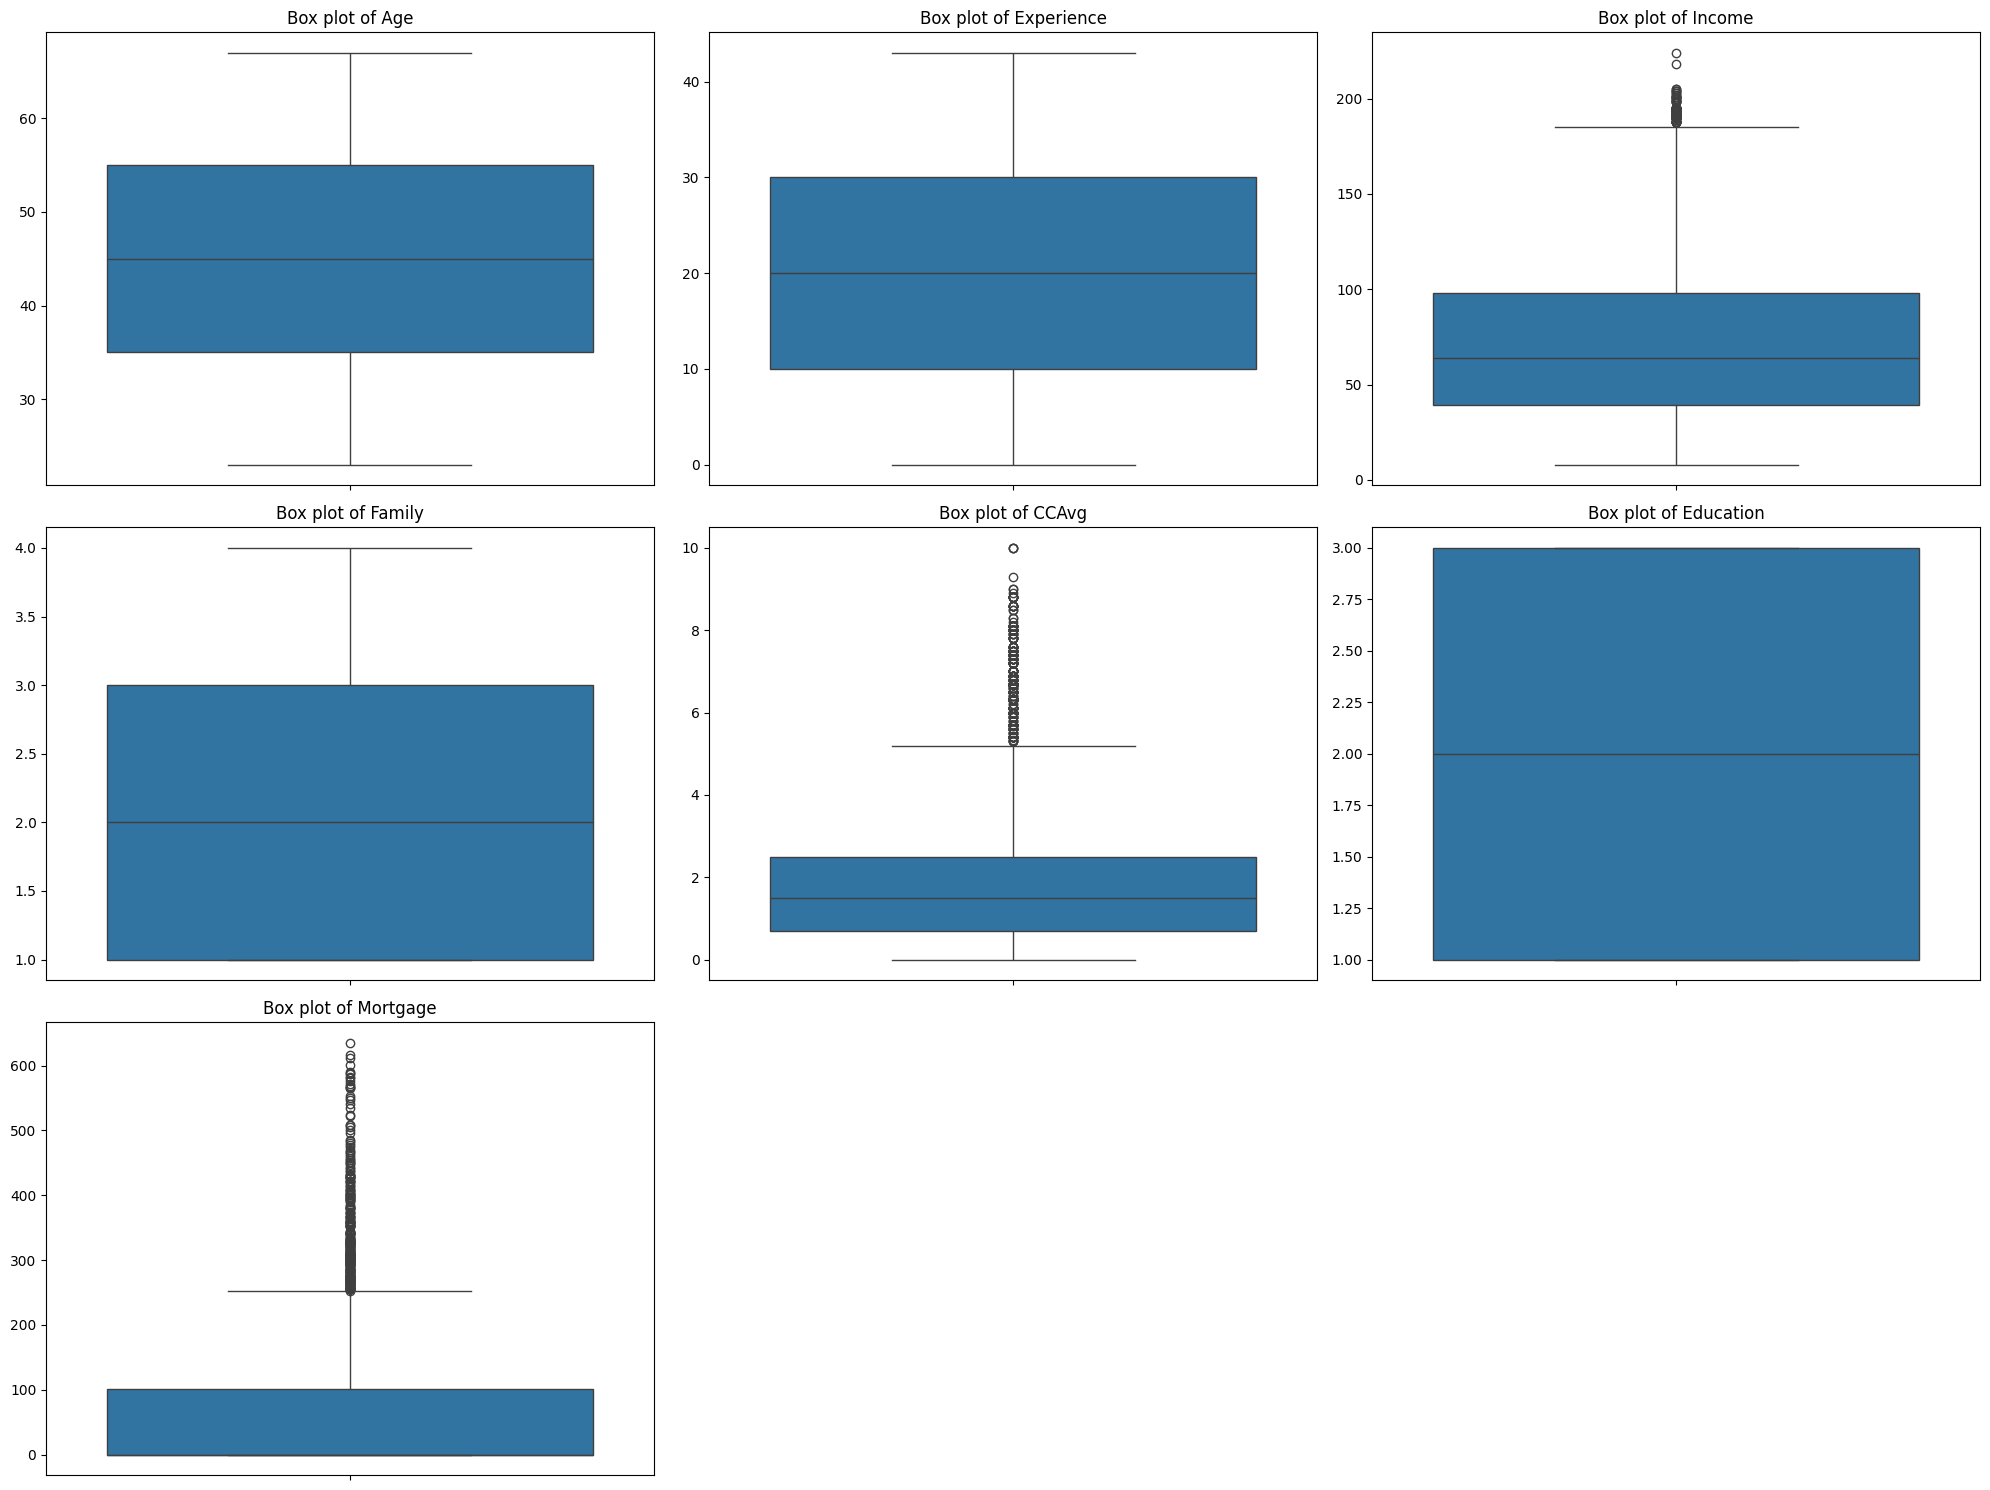

In [ ]:
# outlier detection using boxplot
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

# Exclude binary columns and ZIPCode from outlier capping as they are not continuous numerical features
# ZIPCode is an identifier, and binary features (0/1) don't have traditional outliers.
columns_to_exclude = ['Personal_Loan', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard', 'ZIPCode']
columns_for_outlier_check = [col for col in numeric_columns if col not in columns_to_exclude]

# Plot box plots for numerical columns to detect outliers
plt.figure(figsize=(20, 15))

for i, variable in enumerate(columns_for_outlier_check):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed based on number of columns
    sns.boxplot(y=df[variable], whis=1.5)
    plt.title(f'Box plot of {variable}')
    plt.ylabel('') # Clear y-axis label for cleaner plots

plt.tight_layout()
plt.show()

#### Observations from Outlier Detection:

From the box plots, we can clearly see that Income, CCAvg, and Mortgage exhibit a significant number of outliers in their upper ranges. These are the primary candidates for outlier treatment through capping to ensure they do not unduly influence our predictive model.

### Outlier Treatment

We will now implement a capping strategy for the identified numerical columns (`Income`, `CCAvg`, `Mortgage`). This involves replacing values outside the interquartile range (IQR) boundaries with the respective whisker values. This method helps to normalize the distribution of these features without removing valuable data points.

In [ ]:
# Function to cap outliers using the IQR method
def cap_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_whisker = Q1 - 1.5 * IQR
    upper_whisker = Q3 + 1.5 * IQR

    # Apply capping
    data[column] = np.where(data[column] < lower_whisker, lower_whisker, data[column])
    data[column] = np.where(data[column] > upper_whisker, upper_whisker, data[column])
    return data

# Columns to apply outlier capping
columns_to_cap = ['Income', 'CCAvg', 'Mortgage']

# Apply capping to the identified columns
for col in columns_to_cap:
    df_without_outlier = df.copy()
    df_without_outlier = cap_outliers(df.copy(), col) # Use .copy() to avoid SettingWithCopyWarning

print("Outliers capped for Income, CCAvg, and Mortgage.")

# Verify the effect of capping by re-checking descriptive statistics for capped columns
print("\nDescriptive statistics before capping:")
display(df[columns_to_cap].describe().T)
print("\nDescriptive statistics after capping:")
display(df_without_outlier[columns_to_cap].describe().T)

Outliers capped for Income, CCAvg, and Mortgage.

Descriptive statistics before capping:


,count,mean,std,min,25%,50%,75%,max
Income,5000.0,73.774200,46.033729,8.0,39.0,64.0,98.0,224.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.7,1.5,2.5,10.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.0,0.0,101.0,635.0



Descriptive statistics after capping:


,count,mean,std,min,25%,50%,75%,max
Income,5000.0,73.774200,46.033729,8.0,39.0,64.0,98.0,224.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.7,1.5,2.5,10.0
Mortgage,5000.0,50.494700,83.005401,0.0,0.0,0.0,101.0,252.5


#### Observation:


*   We have done the outlier capping on the data with outliers, and apart from Mortgage, all the data seems to be same.
*   We will be using data with outlier for further analysis, as it might add some more insights in model as we can see there are signifant amount of outliers existence between 252 to 600.



## Data Preparation for Modeling

In [ ]:
X = df.drop(["Personal_Loan"], axis=1)
Y = df["Personal_Loan"]

X = pd.get_dummies(X, drop_first=True)

X = X.astype(float)

# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=42
)

In [ ]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (3500, 12)
Shape of test set :  (1500, 12)
Percentage of classes in training set:
Personal_Loan
0    0.907714
1    0.092286
Name: proportion, dtype: float64
Percentage of classes in test set:
Personal_Loan
0    0.895333
1    0.104667
Name: proportion, dtype: float64


##### Observations:
*   We can see there are ~90% data with `0` Personal_Loan and ~10% data with `1` Personal_Loan, and the behaviour is closely same for both training and testing data.


## Model Building

### Choosing the Metric

Given the imbalanced nature of our target variable (`Personal_Loan`), where only about 9.5% of customers have accepted a personal loan, **accuracy is not a suitable evaluation metric**. A model that simply predicts '0' (no loan) for all instances could achieve ~90% accuracy, but it would be useless for identifying potential loan customers.

Therefore, we will focus on metrics that are more robust to class imbalance:
*   **Precision:** The proportion of positive identifications that were actually correct. High precision means fewer false positives (less wasted marketing efforts).
*   **Recall (Sensitivity):** The proportion of actual positives that were identified correctly. High recall means fewer false negatives (fewer missed opportunities).
*   **F1-Score:** The harmonic mean of precision and recall. It tries to find a balance between the two and is particularly useful when you need to strike a balance between precision and recall, and when classes are imbalanced.

For this business problem, both false positives (marketing to someone who won't take a loan) and false negatives (missing a potential loan customer) have costs. **F1-score** will be a good primary metric as it balances these concerns.

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Building a Decision Tree Model (Unpruned)

In [ ]:
model0 = DecisionTreeClassifier(random_state=42)
model0.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

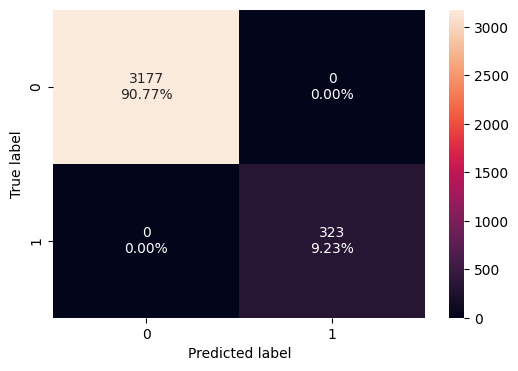

In [ ]:
confusion_matrix_sklearn(model0, X_train, y_train)

In [ ]:
decision_tree_default_perf_train = model_performance_classification_sklearn(
    model0, X_train, y_train
)
decision_tree_default_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


#### Observation:


*   Our model has done fantastic job on training data set with 100% accuracy.



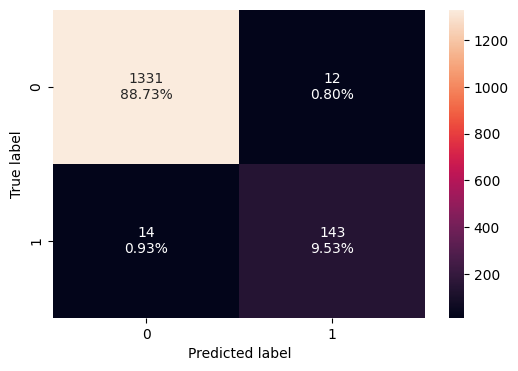

In [ ]:
confusion_matrix_sklearn(model0, X_test, y_test)

In [ ]:
decision_tree_default_perf_test = model_performance_classification_sklearn(
    model0, X_test, y_test
)
decision_tree_default_perf_test

,Accuracy,Recall,Precision,F1
0,0.982667,0.910828,0.922581,0.916667


#### Observation:


* F1 has been dropped from 1 to 0.89 along with other metric as well.
* As seen in the above metrics with testing data set, model performance has been dipped down, which shows a clear case of overfitting.



### Let's try with balanced class weight and see the behaviour of model

In [ ]:
model1 = DecisionTreeClassifier(random_state=42, class_weight="balanced")
model1.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

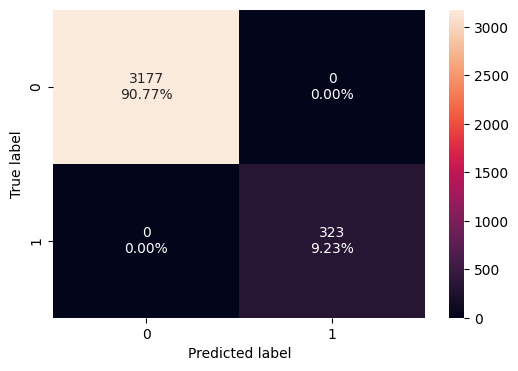

In [ ]:
confusion_matrix_sklearn(model1, X_train, y_train)

In [ ]:
decision_tree_perf_train = model_performance_classification_sklearn(
    model1, X_train, y_train
)
decision_tree_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


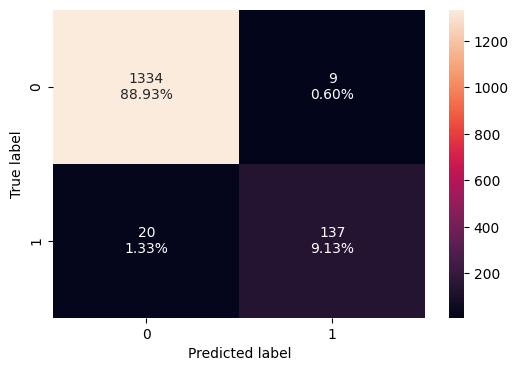

In [ ]:
confusion_matrix_sklearn(model1, X_test, y_test)

In [ ]:
decision_tree_perf_test = model_performance_classification_sklearn(
    model1, X_test, y_test
)
decision_tree_perf_test

,Accuracy,Recall,Precision,F1
0,0.980667,0.872611,0.938356,0.90429


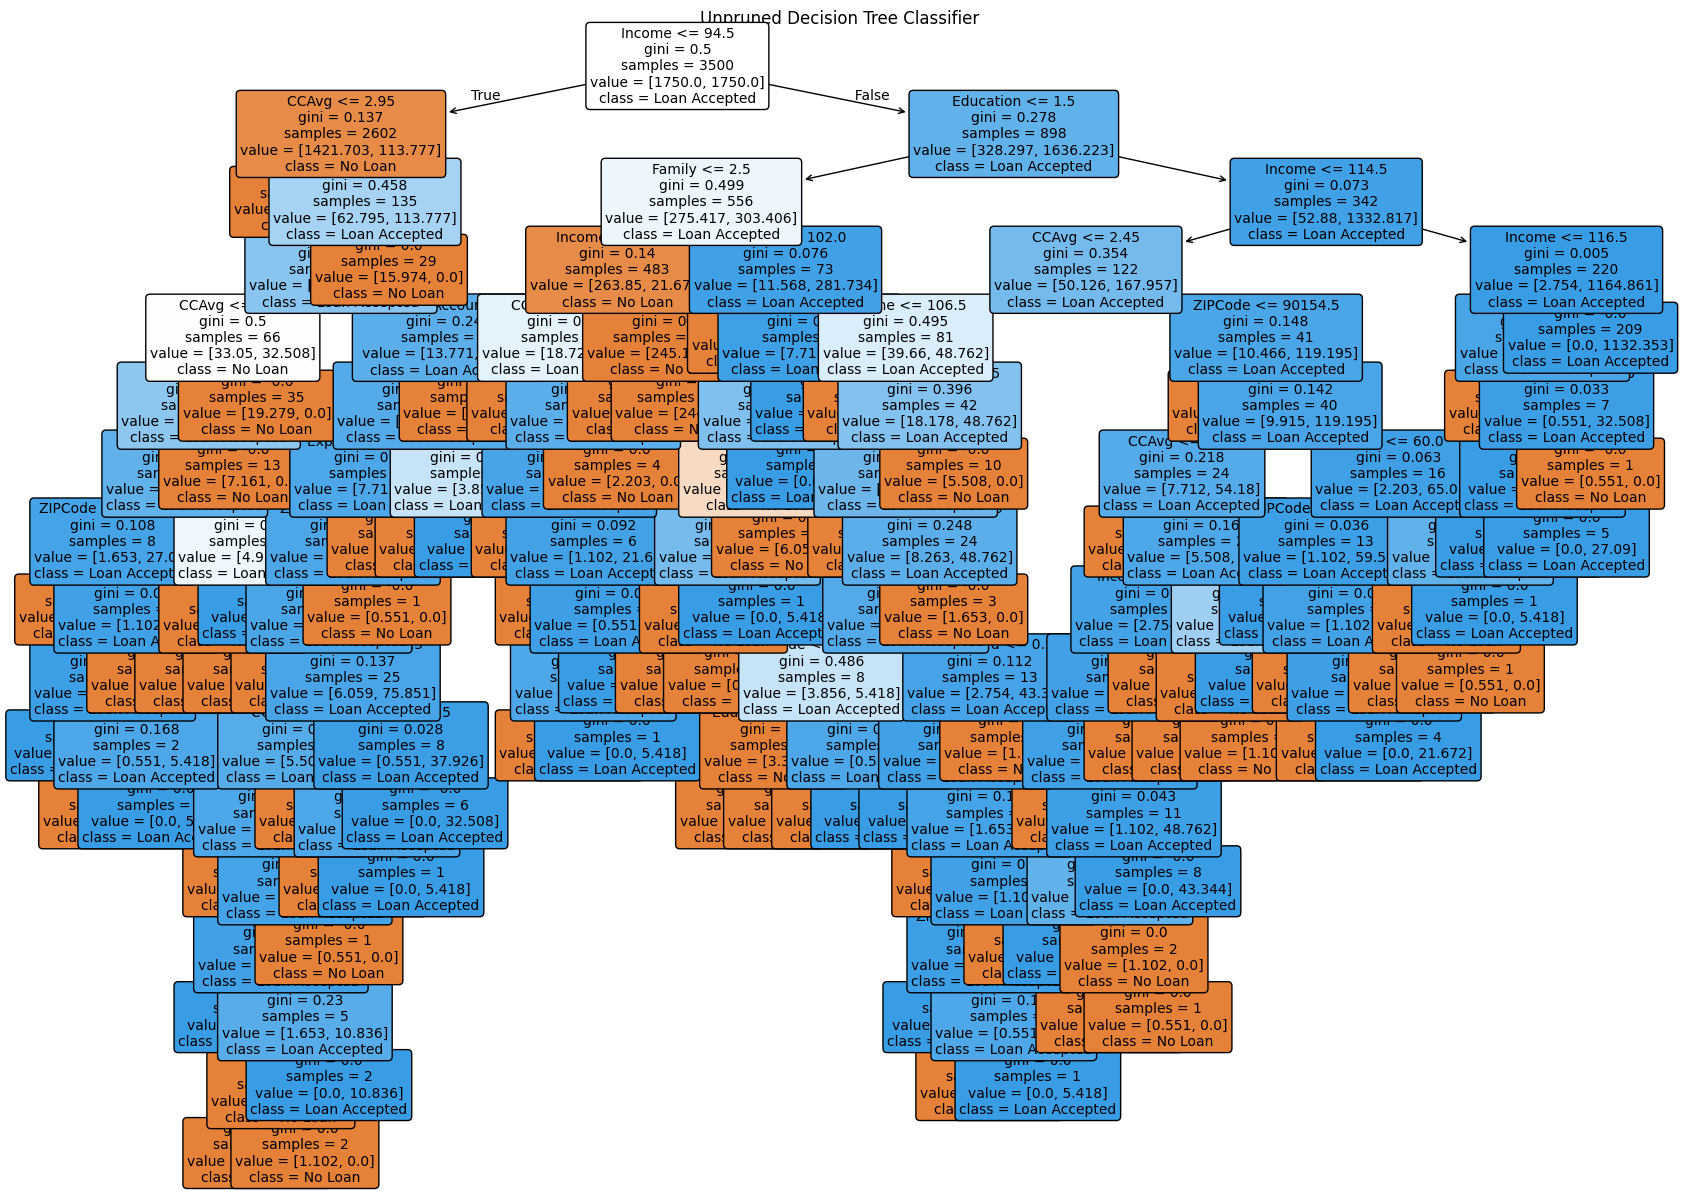

In [ ]:
plt.figure(figsize=(20, 15))
tree.plot_tree(model1, filled=True, feature_names=X_train.columns, class_names=['No Loan', 'Loan Accepted'], rounded=True, fontsize=10)
plt.title('Unpruned Decision Tree Classifier')
plt.show()

#### Observation:

* Balanced model is also showing same kind of overfitting behaviour with 1 F1 score in Train data but 0.91 F1 score with Test data.
* Same behaviour can be seen for other metric as well.
*   The unpruned decision tree is very complex and deep, as expected. This complexity is a strong indicator of overfitting to the training data.
*   Many terminal (leaf) nodes might contain only a few samples, which can lead to poor generalization on unseen data.
*   It's challenging to interpret the decision rules from such a large tree, reinforcing the need for pruning to simplify the model and improve interpretability.
*   The tree likely captures noise in the training data rather than underlying patterns.

**Let's go for pruning technique to reducing overfitting**

## Decision Tree (Pre-pruning)

In [ ]:
max_depth_values = [2, 4, 6, 8]
max_leaf_nodes_values = [10, 20, 30, 40]
min_samples_split_values = [30, 50, 70, 90]
min_samples_leaf_values = [5, 10, 20, 30, 50]



# Initialize variables to store the best model
best_estimator = None
best_test_f1_score = 0.0
best_score_diff = float('inf')

# Iterate through all parameter combinations
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:
          for min_samples_leaf in min_samples_leaf_values:

            # Initialize Decision Tree
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
                class_weight='balanced',
                random_state=42
            )

            # Train the model
            estimator.fit(X_train, y_train)

            # Predictions
            y_train_pred = estimator.predict(X_train)
            y_test_pred = estimator.predict(X_test)

            # Calculate F1 scores
            train_f1 = f1_score(y_train, y_train_pred)
            test_f1 = f1_score(y_test, y_test_pred)

            # Calculate difference between train and test scores
            score_diff = abs(train_f1 - test_f1)

            # Select best model
            if (test_f1 > best_test_f1_score
                      or (test_f1 == best_test_f1_score
                      and score_diff < best_score_diff)):
                best_test_f1_score = test_f1
                best_score_diff = score_diff
                best_estimator = estimator

# Print the best parameters
print("Best Model Parameters:")

print(f"Max Depth: {best_estimator.max_depth}")
print(f"Max Leaf Nodes: {best_estimator.max_leaf_nodes}")
print(f"Min Samples Split: {best_estimator.min_samples_split}")
print(f"Min Samples Leaf: {best_estimator.min_samples_leaf}")
print("\nModel Performance:")
print(f"Best Test F1 Score: {best_test_f1_score:.4f}")
print(f"Train-Test F1 Difference: {best_score_diff:.4f}")

Best Model Parameters:
Max Depth: 8
Max Leaf Nodes: 20
Min Samples Split: 30
Min Samples Leaf: 10

Model Performance:
Best Test F1 Score: 0.8876
Train-Test F1 Difference: 0.0220


#### Observation



*   After Pre-pruning classification we've found our best model with F1 score on Test data approx same as earlier with a minimal dip from ~0.91 to 0.88, but the Train-Test F1 difference is also came to 0.02 which is very minimal as compared to earlier.
*   We have moved our model from overfitting to a model in good shape.



In [ ]:
# creating an instance of the best model
model2 = best_estimator

# fitting the best model to the training data
model2.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=8, max_leaf_nodes=20,
                       min_samples_leaf=10, min_samples_split=30,
                       random_state=42)

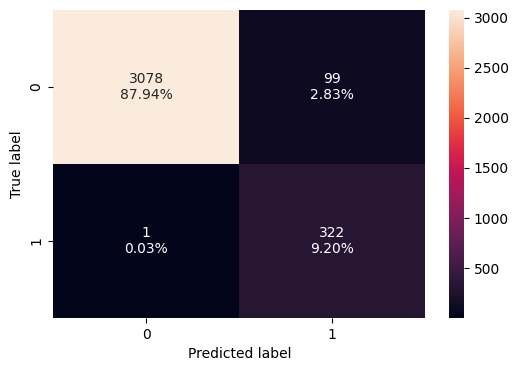

In [ ]:
confusion_matrix_sklearn(model2, X_train, y_train)

In [ ]:
decision_tree_tune_perf_train = model_performance_classification_sklearn(
    model2, X_train, y_train
)
decision_tree_tune_perf_train

,Accuracy,Recall,Precision,F1
0,0.971429,0.996904,0.764846,0.865591


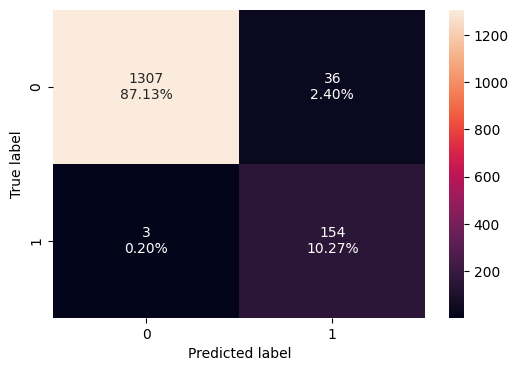

In [ ]:
confusion_matrix_sklearn(model2, X_test, y_test)

In [ ]:
decision_tree_tune_perf_test = model_performance_classification_sklearn(
    model2, X_test, y_test
)
decision_tree_tune_perf_test

,Accuracy,Recall,Precision,F1
0,0.974,0.980892,0.810526,0.887608


#### Observation:


*   After Pre Pruning, we have got F1 score 0.86 on train data but 0.88 on test data which shows growth on test data.
*   Recall has been dipped on test data by 0.01, however there is a jump on other metrics.



In [ ]:
feature_names = list(X_train.columns)
importances = model2.feature_importances_
indices = np.argsort(importances)

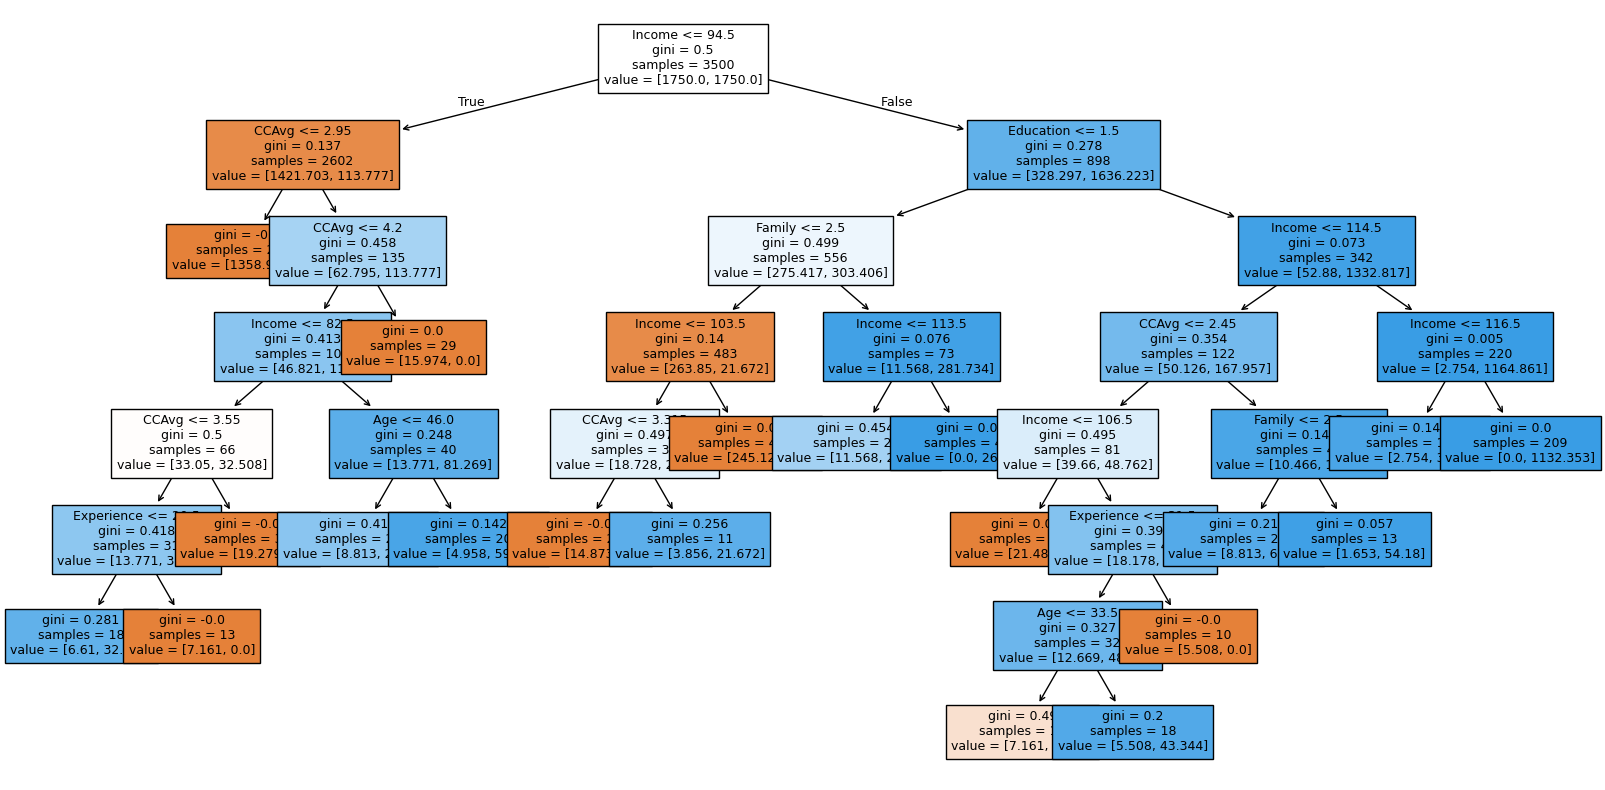

In [ ]:
plt.figure(figsize=(20, 10))
out = tree.plot_tree(
    model2,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [ ]:
# Text report showing the rules of a decision tree -
print(tree.export_text(model2, feature_names=feature_names, show_weights=True))

|--- Income <= 94.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1358.91, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CCAvg <= 4.20
|   |   |   |--- Income <= 82.50
|   |   |   |   |--- CCAvg <= 3.55
|   |   |   |   |   |--- Experience <= 20.50
|   |   |   |   |   |   |--- weights: [6.61, 32.51] class: 1
|   |   |   |   |   |--- Experience >  20.50
|   |   |   |   |   |   |--- weights: [7.16, 0.00] class: 0
|   |   |   |   |--- CCAvg >  3.55
|   |   |   |   |   |--- weights: [19.28, 0.00] class: 0
|   |   |   |--- Income >  82.50
|   |   |   |   |--- Age <= 46.00
|   |   |   |   |   |--- weights: [8.81, 21.67] class: 1
|   |   |   |   |--- Age >  46.00
|   |   |   |   |   |--- weights: [4.96, 59.60] class: 1
|   |   |--- CCAvg >  4.20
|   |   |   |--- weights: [15.97, 0.00] class: 0
|--- Income >  94.50
|   |--- Education <= 1.50
|   |   |--- Family <= 2.50
|   |   |   |--- Income <= 103.50
|   |   |   |   |--- CCAvg <= 3.31
|   |   |   |   |   |--- weights: [14.87, 0.00] clas

#### Observation:

Using the above extracted decision rules we can make interpretations from the decision tree model like:

* If the income is less than or equal to 94.50 thousands dollar, credit card average spend is below 2.45, education is undergrad and age is below 33, then they are most likely to avoid personal loan.

In [ ]:
importances = model2.feature_importances_
importances

array([0.0036452 , 0.00889531, 0.64389017, 0.        , 0.13706394,
       0.11205199, 0.0944534 , 0.        , 0.        , 0.        ,
       0.        , 0.        ])

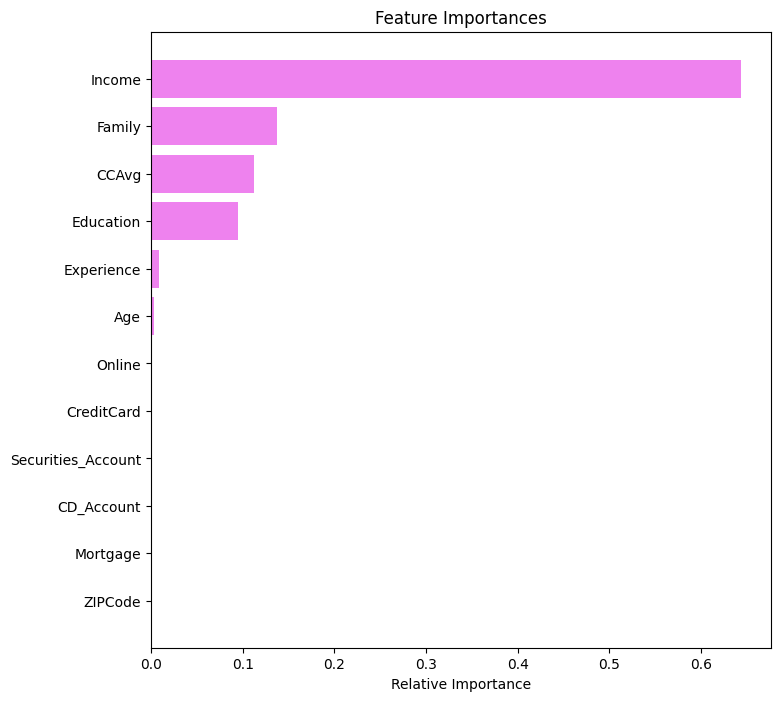

In [ ]:
# importance of features in the tree building

importances = model2.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

#### Observation
* In the pre-puned data, Income is playing most significant role, followed by Family, CCAvg, Education and then experience.

## Decision Tree (Post-pruning)

#### We will try Cost complexity pruning as well to see the behaviour of our model, and then pick the best fit model accordingly.

In [ ]:
clf = DecisionTreeClassifier(random_state=42)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = abs(path.ccp_alphas), path.impurities

In [ ]:
pd.DataFrame(path).sample(10)

,ccp_alphas,impurities
13,0.000535,0.007648
26,0.000990,0.021129
20,0.000629,0.015765
22,0.000794,0.017321
10,0.000490,0.005550
18,0.000558,0.011468
33,0.024483,0.063407
24,0.000940,0.019151
21,0.000762,0.016527
9,0.000468,0.005060


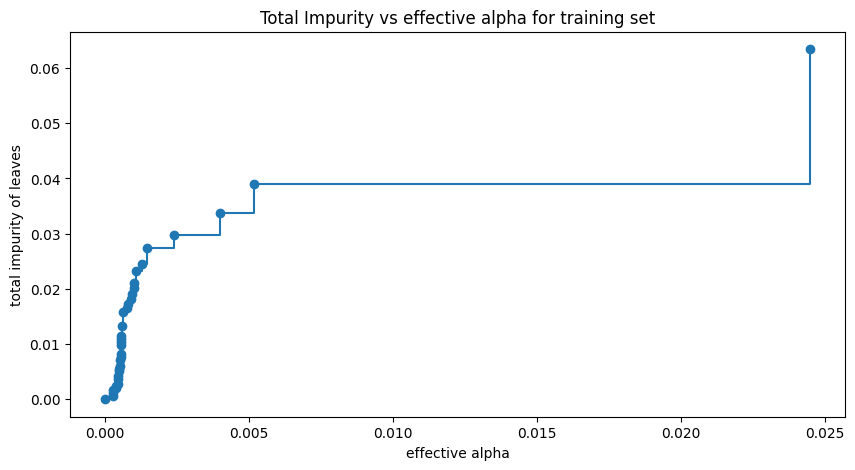

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

##### Observations on Total Impurity vs effective alpha for training set:

* As `ccp_alpha` increases, the total impurity of leaves increases. This is expected as higher alpha values lead to more pruning, resulting in fewer, larger leaves and thus higher impurity.

In [ ]:
# Train a series of Decision Tree models for different ccp_alphas
dts = []
for ccp_alpha in ccp_alphas:
    dt = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    dt.fit(X_train, y_train)
    dts.append(dt)

In [ ]:
# Evaluate the models on the train set and find the best ccp_alpha based on F1-score
f1_scores_train = [f1_score(y_train, dt.predict(X_train)) for dt in dts]

In [ ]:
# Evaluate the models on the test set and find the best ccp_alpha based on F1-score
f1_scores_test = [f1_score(y_test, dt.predict(X_test)) for dt in dts]

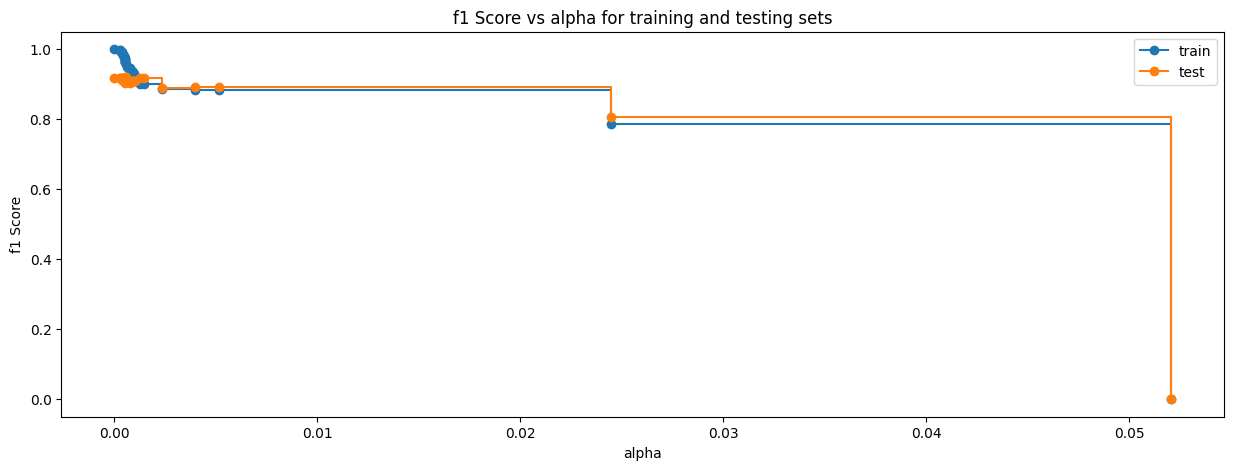

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("f1 Score")
ax.set_title("f1 Score vs alpha for training and testing sets")
ax.plot(
    ccp_alphas, f1_scores_train, marker="o", label="train", drawstyle="steps-post",
)
ax.plot(ccp_alphas, f1_scores_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

##### Observations on F1 Score vs effective alpha:

*   For small `ccp_alpha` values, the model tends to overfit, as indicated by a high training F1 score (close to 1) and a slightly lower test F1 score. This is the unpruned or minimally pruned tree.
*   As `ccp_alpha` increases, the training F1 score generally decreases because the tree becomes simpler and less capable of perfectly fitting the training data.
*   The test F1 score initially remains relatively stable or even slightly increases as the model starts to generalize better by removing less important splits.
*   There's an optimal `ccp_alpha` value where the test F1 score peaks. Beyond this point, further increases in `ccp_alpha` lead to excessive pruning, causing both training and test F1 scores to drop significantly, indicating underfitting.
*   The plot helps identify the range of `ccp_alpha` values that balance model complexity and generalization ability.

In [ ]:
# Find the index of the best f1_score
best_alpha_idx = np.argmax(f1_scores_test)
best_ccp_alpha = ccp_alphas[best_alpha_idx]

print(f"\nOptimal ccp_alpha for post-pruning: {best_ccp_alpha:.4f}")


Optimal ccp_alpha for post-pruning: 0.0006


In [ ]:
# Train the final post-pruned model with the optimal ccp_alpha
post_pruned_dt_model = DecisionTreeClassifier(random_state=42, ccp_alpha=best_ccp_alpha)
post_pruned_dt_model.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.000593615745418402),
                       random_state=42)

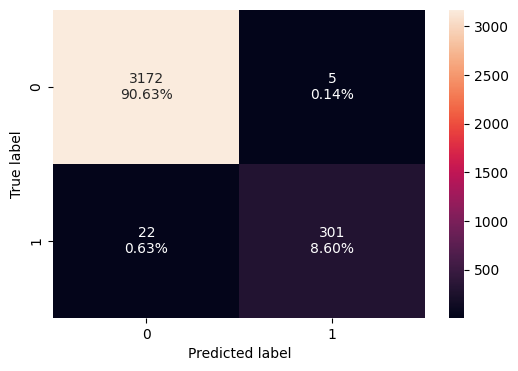

In [ ]:
confusion_matrix_sklearn(post_pruned_dt_model, X_train, y_train)

In [ ]:
decision_tree_post_tune_perf_train = model_performance_classification_sklearn(
    post_pruned_dt_model, X_train, y_train
)
decision_tree_post_tune_perf_train

,Accuracy,Recall,Precision,F1
0,0.992286,0.931889,0.98366,0.957075


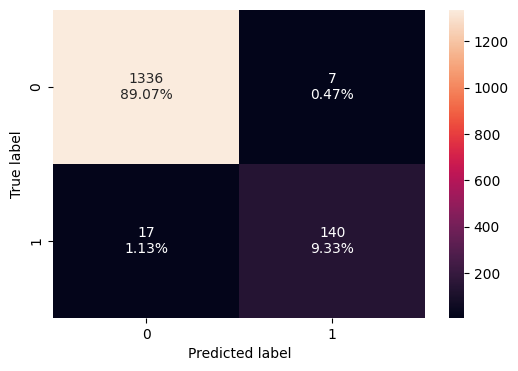

In [ ]:
confusion_matrix_sklearn(post_pruned_dt_model, X_test, y_test)

In [ ]:
decision_tree_post_tune_perf_test = model_performance_classification_sklearn(
    post_pruned_dt_model, X_test, y_test
)
decision_tree_post_tune_perf_test

,Accuracy,Recall,Precision,F1
0,0.984,0.89172,0.952381,0.921053


##### Observations:

* After Post Pruning, we have got F1 score 0.95 on train data and 0.92 on test data which looks good.
* Recall has been dipped on test data from 0.93 to 0.89.



### Visualizing the Post-pruned Decision Tree

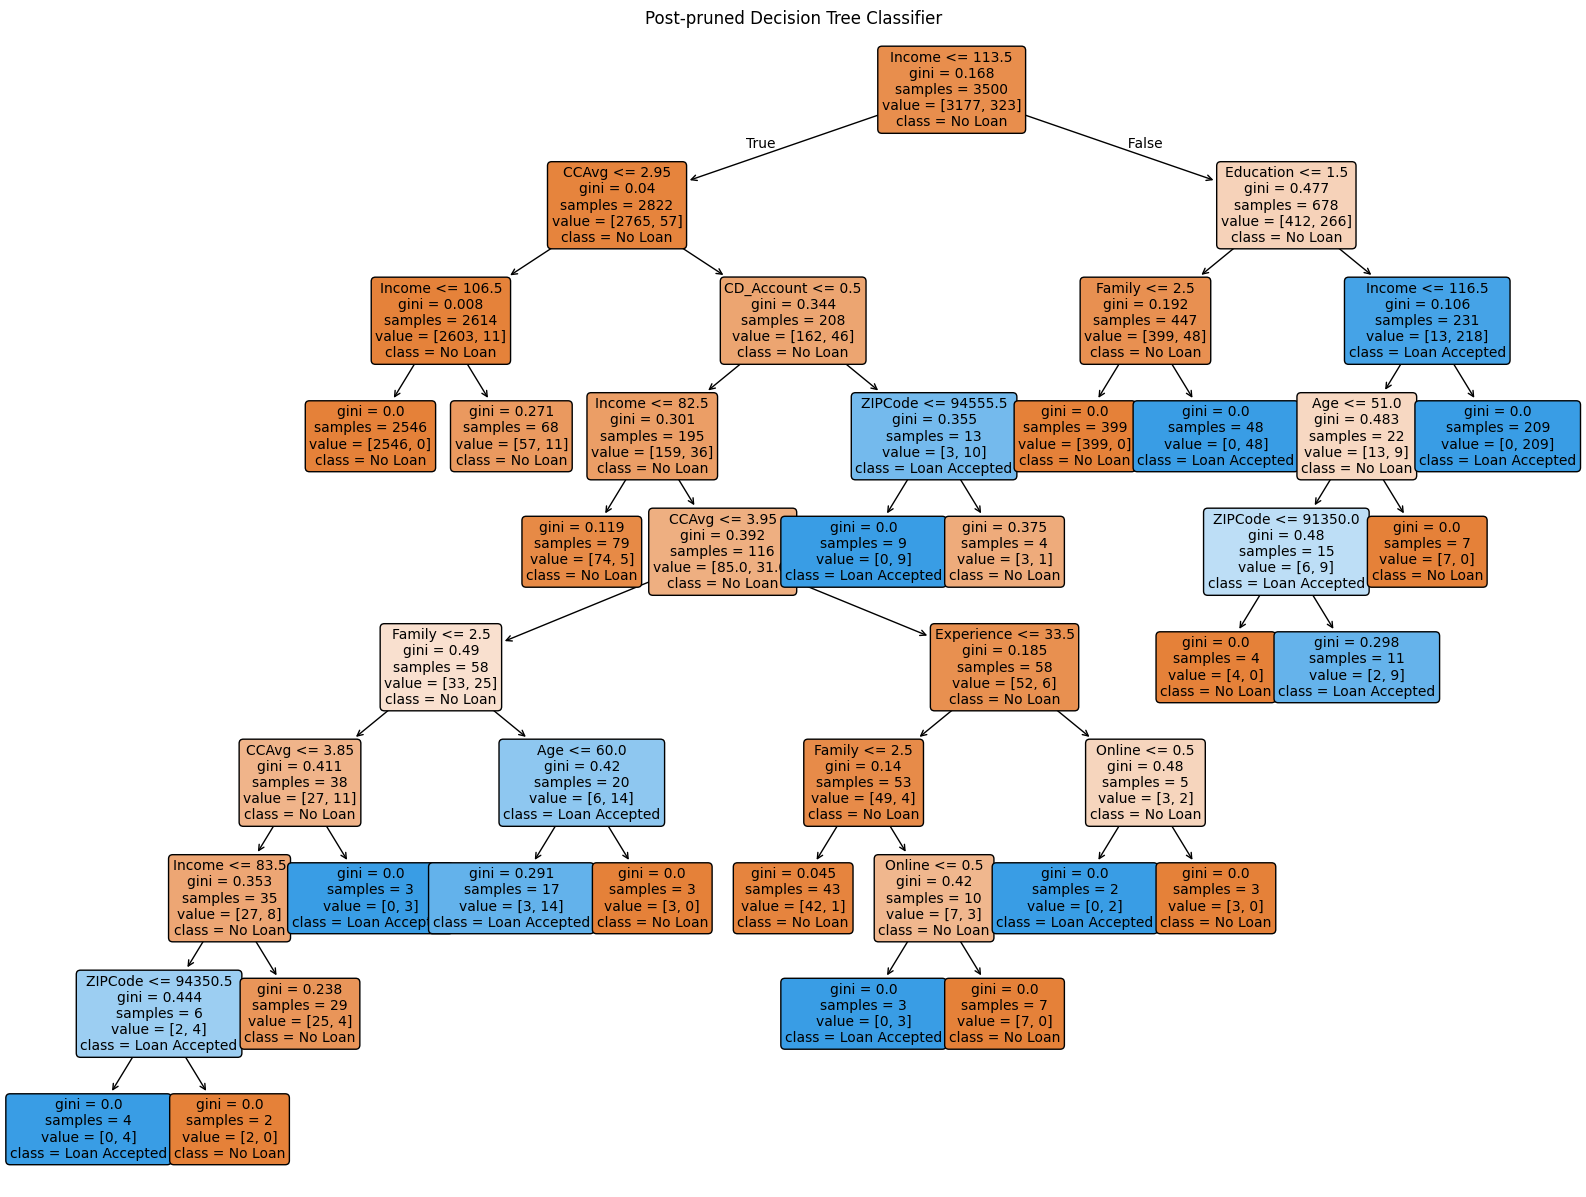

In [ ]:
plt.figure(figsize=(20, 15))
tree.plot_tree(post_pruned_dt_model, filled=True, feature_names=X_train.columns, class_names=['No Loan', 'Loan Accepted'], rounded=True, fontsize=10)
plt.title('Post-pruned Decision Tree Classifier')
plt.show()

##### Observations on Post-pruned Decision Tree Visualization:

*   The post-pruned tree is simpler as compared to the unpruned decision tree and pre-pruned tree.
*   It appears to be similar structure complexity as compared pre-pruned tree possibly capturing more relevant patterns while still avoiding excessive complexity.
*   Similar to the pre-pruned tree, `Income`, `CCAvg`, and `Education` remain prominent features in the decision-making process.

### Summary of Model Performance and Comparison

In [ ]:
# testing performance comparison

models_train_comp_df = pd.concat(
    [
        decision_tree_default_perf_test.T,
        decision_tree_perf_test.T,
        decision_tree_tune_perf_test.T,
        decision_tree_post_tune_perf_test.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree with class_weight",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Testing performance comparison:")
models_train_comp_df

Testing performance comparison:


,Decision Tree (sklearn default),Decision Tree with class_weight,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.982667,0.980667,0.974000,0.984000
Recall,0.910828,0.872611,0.980892,0.891720
Precision,0.922581,0.938356,0.810526,0.952381
F1,0.916667,0.904290,0.887608,0.921053


After building and evaluating four Decision Tree models (sklearn default, decision tree with class weight, pre-pruned, and post-pruned), we have found that post-prunned model `post_pruned_dt_model` is best fit for this analysis.


**Observations:**

*   **Overfitting Reduction:** Both pruning techniques successfully reduced the gap between training and testing F1-scores, indicating better generalization compared to the highly overfit unpruned model.
*   **Performance:** The **Post-pruned Decision Tree model** (using `ccp_alpha`) achieved the **highest test F1-score of 0.92**, along with the best accuracy, precision on the test set among the three models. However, **recall is around 0.89** in post-pruned data which is significantly less than pre-pruned data. This model demonstrates the best balance between identifying actual loan acceptors (recall) and ensuring those predictions are correct (precision).
*   **Model Selection:** Based on the superior F1-score and improved generalization, the **Post-pruned Decision Tree model (`post_pruned_dt_model`)** is selected as the best performing model for this problem.

### Feature Importance of the Best Model

Top 10 Feature Importances:
       feature  importance
6    Education    0.394533
2       Income    0.324922
4       Family    0.169164
5        CCAvg    0.051201
3      ZIPCode    0.017980
9   CD_Account    0.015427
0          Age    0.012769
10      Online    0.012222
1   Experience    0.001782
7     Mortgage    0.000000


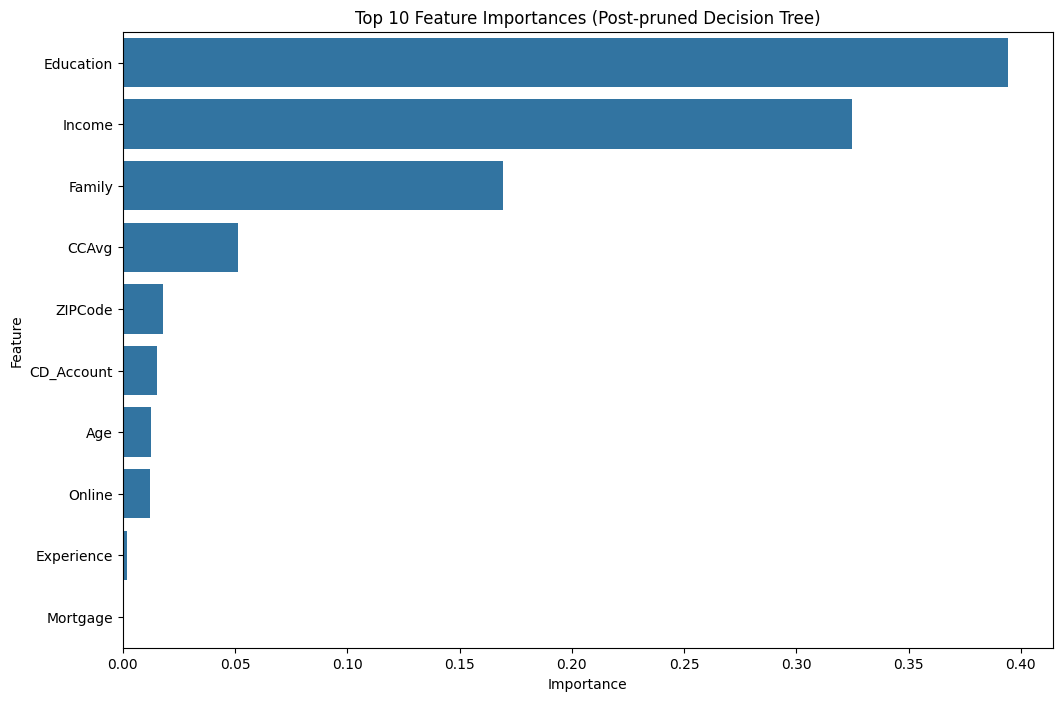

In [ ]:
# Get feature importances from the best model
importances = post_pruned_dt_model.feature_importances_

# Create a DataFrame for better visualization
feature_importances = pd.DataFrame({'feature': X_train.columns, 'importance': importances})

# Sort by importance in descending order
feature_importances = feature_importances.sort_values(by='importance', ascending=False)

# Print and visualize feature importances
print("Top 10 Feature Importances:")
print(feature_importances.head(10))

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importances.head(10))
plt.title('Top 10 Feature Importances (Post-pruned Decision Tree)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

##### Observations on Feature Importance:

*   **Education** is the most important feature with an importance of approximately 0.39, indicating it has the strongest influence on predicting personal loan acceptance.
*   **Income** comes in second with an importance of about 0.32, reinforcing its strong predictive power, as seen in earlier EDA and model splits.
*   **Family** size is also a significant predictor, with an importance of approximately 0.169.
*   **CCAvg** (average credit card spending) contributes about 0.051 to the model's decision-making.
*   Features like `ZIPCode`, `CD_Account`, `Age` and `Online` have minor importance.
*   `Experience`, `Mortgage`, `Securities_Account` show very low to zero importance in this model, suggesting they are less influential in predicting personal loan acceptance when considered alongside other stronger features.

### Actionable Insights and Recommendations

**1. Target High-Education, High-Income Customers, living with family with High Credit Card Usage:**

*   **Insight:** `Education`, `Income`, `Family` and `CCAvg` are the most significant predictors of personal loan acceptance. Customers with higher education levels (especially Advanced/Professional), higher incomes, having more than 1 family member and greater credit card spending habits are much more likely to accept a personal loan.
*   **Recommendation:** Focus marketing efforts on existing customers who fall into these high-value segments. Develop highly personalized offers that align with their financial capacity and educational background. For example, offer specialized loans for further education, career development, or wealth management for highly educated, high-income individuals. Highlight competitive interest rates and flexible terms.

**2. Capitalize on CD Account Holders for Cross-Selling:**

*   **Insight:** Customers with a Certificate of Deposit (CD) account show a notably higher propensity to accept personal loans.
*   **Recommendation:** Implement a targeted cross-selling campaign for CD account holders. These customers already demonstrate trust in the bank for savings and might be open to expanding their relationship. Tailor messages to show how a personal loan can help them achieve short-term financial goals without liquidating their long-term CD investments, or fund other significant purchases.

**3. Consider Family Size for Tailored Product Offerings:**

*   **Insight:** `Family` size is a substantial feature in the decision tree, suggesting varying financial needs based on household structure.
*   **Recommendation:** Conduct further market research to understand how different family sizes correlate with specific loan needs. For example, larger families might be interested in loans for home improvement, education for children, or family vacations. Smaller families might prioritize personal development or travel loans. Create and market loan products that specifically cater to these diverse family needs.

**4. Target most repeated zipcode and :**

* **Insight:** `Zip Code` has also correlated with personal loan, that can be utilised for follow up and marketing.
* **Recommendation:** Marketing Team can focus more on the area which has high frequency of personal loan holder, as well as start the Survey around those region which has less personal loan holder, to gather insights around their requirement.

**5. Re-evaluate Less Important Features:**

*   **Insight:** `ZIPCode`, `Mortgage`, `Securities_Account`, `Online`, and `CreditCard` (from other banks) have very low or zero importance in the current model.
*   **Recommendation:** While these features might not be direct drivers, consider if they could be valuable for broader customer segmentation or in combination with other data points not captured by this model. For `Mortgage` and `Securities_Account`, their current low importance could be due to sparsity (many zero values), which might be addressed with feature engineering if deeper analysis is warranted. For `ZIPCode`, it could be used for geographical targeting if there are regional campaigns.